# 02 - Feature Engineering

Neste notebook eu crio uma primeira camada de features financeiras para o projeto de risco de crédito. A ideia é transformar valores absolutos em razões mais comparáveis entre clientes, principalmente quando renda, crédito e anuidade estão em escalas muito diferentes.

Ainda não vou escolher modelo aqui. Esta etapa serve para validar se as novas variáveis fazem sentido, se não geram infinito e se parecem úteis o suficiente para entrar no pipeline de modelagem.

## 1. Imports e configurações

As funções de feature engineering ficam em `src/features/build_features.py`, para que o notebook e o treino usem a mesma lógica.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.build_features import FEATURE_RATIOS, build_features  # noqa: E402, I001
from src.utils.config import DEFAULT_PROCESSED_DATA_PATH, FIGURES_DIR, TARGET_COLUMN  # noqa: E402, I001

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 2. Carregamento dos dados

Vou partir do dataset processado na etapa anterior. Ele ainda preserva as colunas originais necessárias para as razões financeiras.

In [2]:
if not DEFAULT_PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found at {DEFAULT_PROCESSED_DATA_PATH}. "
        "Run: python src/data/make_dataset.py"
    )

df = pd.read_csv(DEFAULT_PROCESSED_DATA_PATH)

print(f"Arquivo carregado: {DEFAULT_PROCESSED_DATA_PATH}")
print(f"Shape original: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas")

Arquivo carregado: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\data\processed\credit_risk_processed.csv
Shape original: 307,511 linhas x 105 colunas


## 3. Features criadas

As novas variáveis são razões simples:

- `CREDIT_INCOME_RATIO`: quanto o valor do crédito representa em relação à renda total.
- `ANNUITY_INCOME_RATIO`: quanto a anuidade representa em relação à renda total.
- `EMPLOYED_AGE_RATIO`: proporção entre dias empregado e idade em dias. No Home Credit, ambas as colunas costumam vir em dias negativos, então a razão tende a ser positiva quando os valores são comuns.
- `CREDIT_ANNUITY_RATIO`: relação entre valor do crédito e anuidade.

Divisões por zero e resultados infinitos são convertidos para `NaN`. Prefiro deixar esses casos explícitos para que a imputação do pipeline trate depois, em vez de colocar um valor artificial nesta etapa.

In [3]:
feature_definitions = pd.DataFrame.from_dict(
    FEATURE_RATIOS,
    orient="index",
    columns=["numerator", "denominator"],
)
display(feature_definitions)

,numerator,denominator
CREDIT_INCOME_RATIO,AMT_CREDIT,AMT_INCOME_TOTAL
ANNUITY_INCOME_RATIO,AMT_ANNUITY,AMT_INCOME_TOTAL
EMPLOYED_AGE_RATIO,DAYS_EMPLOYED,DAYS_BIRTH
CREDIT_ANNUITY_RATIO,AMT_CREDIT,AMT_ANNUITY


In [4]:
features_df = build_features(df)
new_feature_columns = list(FEATURE_RATIOS.keys())

print(f"Shape após feature engineering: {features_df.shape[0]:,} linhas x {features_df.shape[1]:,} colunas")
display(features_df[new_feature_columns].head())

Shape após feature engineering: 307,511 linhas x 109 colunas


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EMPLOYED_AGE_RATIO,CREDIT_ANNUITY_RATIO
0,2.0079,0.1220,0.0673,16.4611
1,4.7908,0.1322,0.0709,36.2341
2,2.0000,0.1000,0.0118,20.0000
3,2.3162,0.2199,0.1599,10.5328
4,4.2222,0.1800,0.1524,23.4616


## 4. Checagens de qualidade

Antes de analisar as distribuições, confiro se as novas colunas foram criadas e se nenhuma delas ficou com valores infinitos. Valores ausentes podem aparecer por renda zero, anuidade zero, dados faltantes ou valores não numéricos.

In [5]:
quality_summary = pd.DataFrame(
    {
        "missing_count": features_df[new_feature_columns].isna().sum(),
        "missing_percent": features_df[new_feature_columns].isna().mean() * 100,
        "infinite_count": np.isinf(features_df[new_feature_columns].to_numpy()).sum(axis=0),
    },
    index=new_feature_columns,
)

display(quality_summary)

,missing_count,missing_percent,infinite_count
CREDIT_INCOME_RATIO,0,0.0000,0
ANNUITY_INCOME_RATIO,12,0.0039,0
EMPLOYED_AGE_RATIO,0,0.0000,0
CREDIT_ANNUITY_RATIO,12,0.0039,0


In [6]:
display(
    features_df[new_feature_columns]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CREDIT_INCOME_RATIO,307511.0000,3.9576,2.6897,0.0048,0.5954,1.0000,2.0187,3.2651,5.1599,9.1567,13.0273,84.7368
ANNUITY_INCOME_RATIO,307499.0000,0.1809,0.0946,0.0002,0.0395,0.0626,0.1148,0.1628,0.2291,0.3547,0.4835,1.8760
EMPLOYED_AGE_RATIO,307511.0000,-2.9201,6.6271,-47.4897,-19.5368,-17.4074,0.0216,0.0886,0.1910,0.4140,0.5790,0.7288
CREDIT_ANNUITY_RATIO,307499.0000,21.6123,7.8238,8.0367,8.7100,9.5235,15.6145,20.0000,27.1000,34.5423,37.7941,45.3051


## 5. Distribuições das novas variáveis

As razões podem ter caudas longas. Para visualizar melhor a parte principal das distribuições, os gráficos abaixo cortam apenas a visualização no percentil 99. Os dados originais continuam preservados no DataFrame.

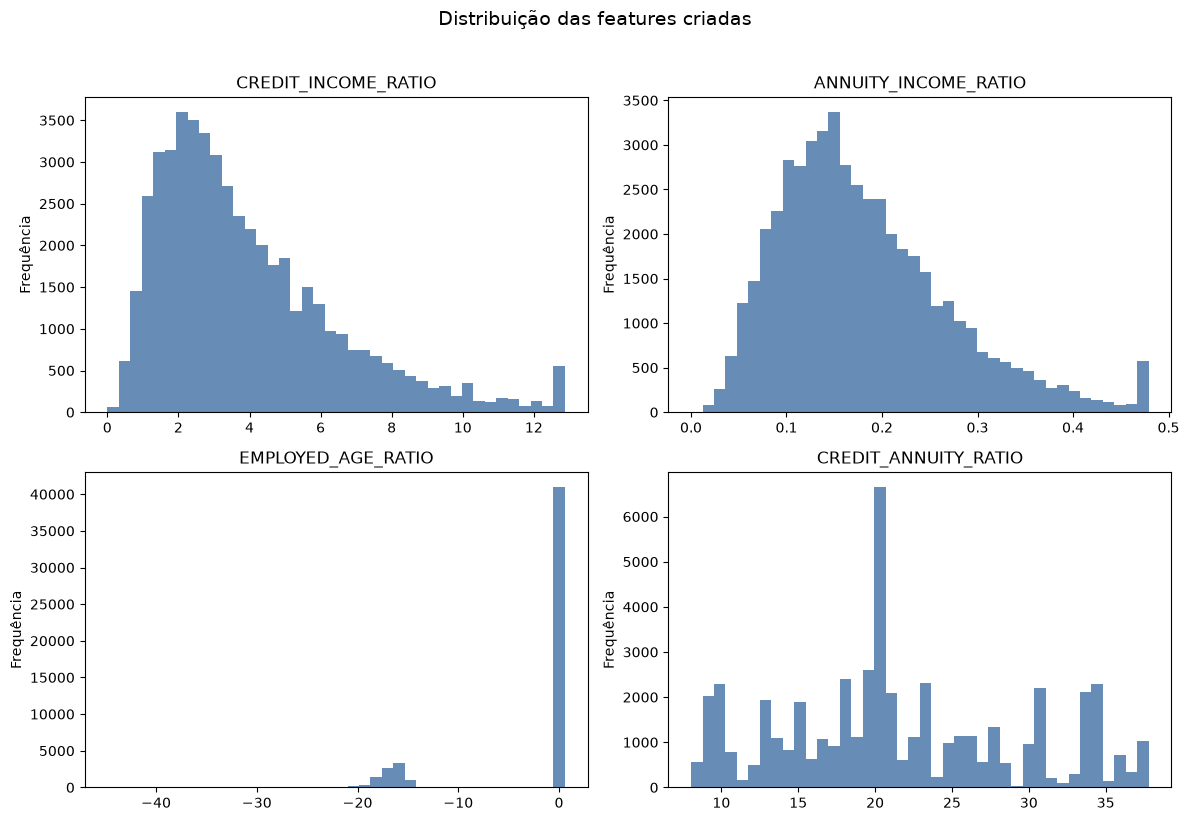

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\feature_ratio_distributions.png


In [7]:
plot_sample = features_df.sample(min(50_000, len(features_df)), random_state=RANDOM_STATE)


def clip_for_plot(series: pd.Series, upper_quantile: float = 0.99) -> pd.Series:
    clean_series = series.dropna()
    upper_limit = clean_series.quantile(upper_quantile)
    return clean_series.clip(upper=upper_limit)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, column in zip(axes, new_feature_columns, strict=True):
    values = clip_for_plot(plot_sample[column])
    ax.hist(values, bins=40, color="#4C78A8", alpha=0.85)
    ax.set_title(column)
    ax.set_ylabel("Frequência")

fig.suptitle("Distribuição das features criadas", y=1.02, fontsize=14)
fig.tight_layout()

feature_dist_path = FIGURES_DIR / "feature_ratio_distributions.png"
fig.savefig(feature_dist_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {feature_dist_path}")

## 6. Comparação por TARGET

Agora comparo as novas features entre as classes do alvo. Nesta etapa eu olho diferenças como pistas para modelagem, não como explicação causal. Um padrão visual pode ser útil para o modelo, mas ainda precisa ser validado com treino, teste e métricas adequadas.

In [8]:
median_by_target = features_df.groupby(TARGET_COLUMN)[new_feature_columns].median().T
median_by_target.columns = [f"TARGET_{column}" for column in median_by_target.columns]

if {"TARGET_0", "TARGET_1"}.issubset(median_by_target.columns):
    median_by_target["relative_diff_target_1_vs_0_%"] = (
        (median_by_target["TARGET_1"] - median_by_target["TARGET_0"])
        / median_by_target["TARGET_0"].replace(0, np.nan)
        * 100
    ).round(2)

display(median_by_target)

,TARGET_0,TARGET_1,relative_diff_target_1_vs_0_%
CREDIT_INCOME_RATIO,3.2667,3.2531,-0.4100
ANNUITY_INCOME_RATIO,0.1623,0.1693,4.3200
EMPLOYED_AGE_RATIO,0.0898,0.0790,-12.0400
CREDIT_ANNUITY_RATIO,20.0000,20.0000,0.0000


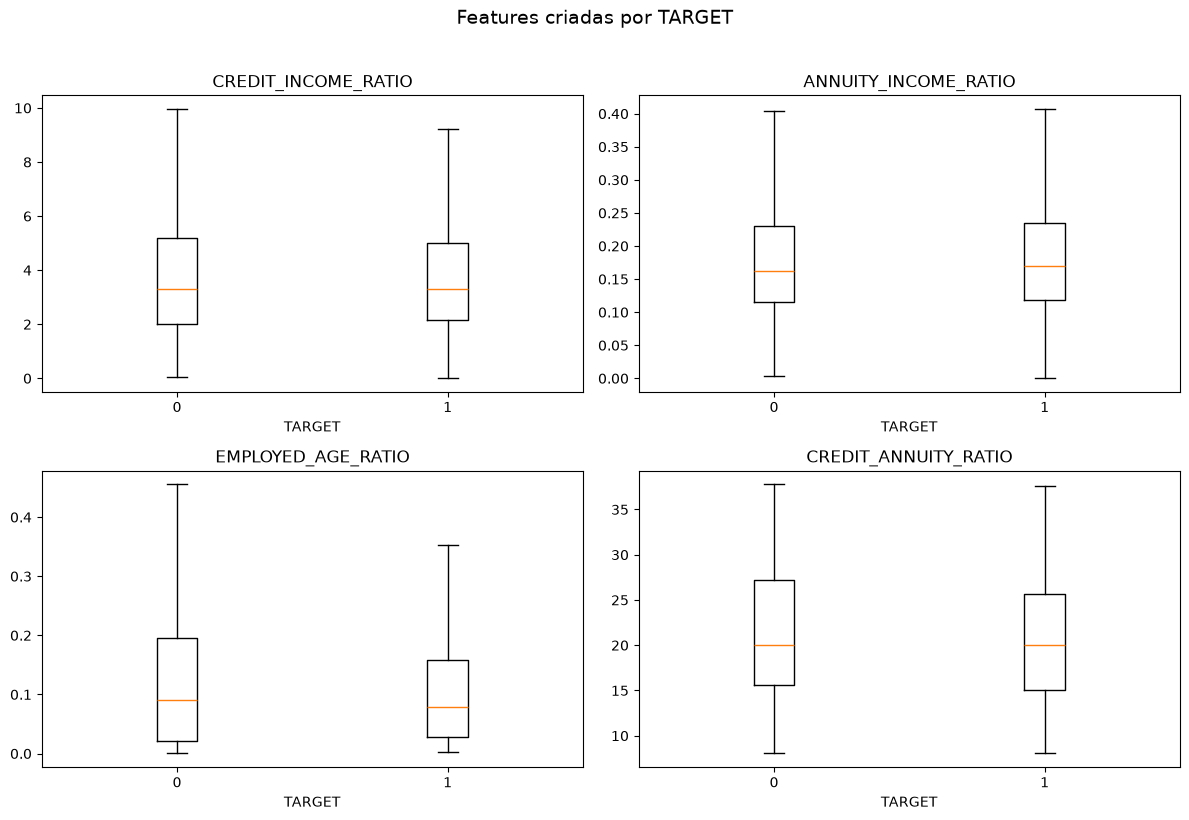

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\feature_ratio_boxplots_by_target.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, column in zip(axes, new_feature_columns, strict=True):
    grouped_values = []
    labels = []

    for target_value in sorted(plot_sample[TARGET_COLUMN].dropna().unique()):
        series = plot_sample.loc[plot_sample[TARGET_COLUMN] == target_value, column]
        grouped_values.append(clip_for_plot(series))
        labels.append(str(target_value))

    ax.boxplot(grouped_values, tick_labels=labels, showfliers=False)
    ax.set_title(column)
    ax.set_xlabel("TARGET")

fig.suptitle("Features criadas por TARGET", y=1.02, fontsize=14)
fig.tight_layout()

feature_target_path = FIGURES_DIR / "feature_ratio_boxplots_by_target.png"
fig.savefig(feature_target_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {feature_target_path}")

## 7. Integração com o pré-processamento

Depois da criação das features, o próximo passo do pipeline será separar `X` e `y` e aplicar imputação, escala para numéricas e one-hot encoding para categóricas. Aqui faço apenas uma checagem rápida de que o DataFrame com novas colunas continua compatível com a etapa seguinte.

In [10]:
from src.features.build_features import build_preprocessor, split_features_target  # noqa: E402, I001

X, y = split_features_target(features_df, TARGET_COLUMN)
preprocessor = build_preprocessor()

X_sample = X.sample(min(2_000, len(X)), random_state=RANDOM_STATE)
transformed_sample = preprocessor.fit_transform(X_sample)

print(f"Target shape: {y.shape}")
print(f"Transformed sample shape: {transformed_sample.shape}")

Target shape: (307511,)
Transformed sample shape: (2000, 216)


## Main takeaways

As observações abaixo são calculadas a partir do dataset carregado. Elas ajudam a guiar a modelagem, mas ainda não dizem se uma feature melhora a performance de fato.

In [11]:
highest_missing_feature = quality_summary["missing_percent"].idxmax()
highest_missing_percent = quality_summary.loc[highest_missing_feature, "missing_percent"]
has_infinite_values = bool(quality_summary["infinite_count"].sum())

takeaways = [
    f"Foram criadas **{len(new_feature_columns)} novas features** financeiras.",
    f"A feature com maior percentual de nulos após as divisões é **`{highest_missing_feature}`**, com **{highest_missing_percent:.4f}%**.",
    f"As novas features {'não têm' if not has_infinite_values else 'ainda têm'} valores infinitos após o tratamento seguro de divisão.",
    "As razões ajudam a comparar contratos em escala relativa, principalmente renda versus crédito e renda versus anuidade.",
    "Na modelagem, essas variáveis devem ser avaliadas junto com validação fora da amostra, porque diferenças visuais por TARGET não são prova de ganho preditivo.",
]

display(Markdown("\n".join(f"- {item}" for item in takeaways)))

- Foram criadas **4 novas features** financeiras.
- A feature com maior percentual de nulos após as divisões é **`ANNUITY_INCOME_RATIO`**, com **0.0039%**.
- As novas features não têm valores infinitos após o tratamento seguro de divisão.
- As razões ajudam a comparar contratos em escala relativa, principalmente renda versus crédito e renda versus anuidade.
- Na modelagem, essas variáveis devem ser avaliadas junto com validação fora da amostra, porque diferenças visuais por TARGET não são prova de ganho preditivo.